## Import needed libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report

c:\Users\Radin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import gaussian_kde


## Loading and Pre-Processing data

In [12]:
## Download FashionMNIST dataset
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
transform = transforms.ToTensor()

train_set = torchvision.datasets.FashionMNIST('./MNIST', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST('./MNIST', train=False, download=True, transform=transform)
#################################################################################
#                                   THE END                                     #
#################################################################################

In [13]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
# split training set into train and validation data
train_size = int(len(train_set) * 0.8)
val_size = len(train_set) - train_size

train_data, val_data = random_split(train_set, [train_size, val_size])
#################################################################################
#                                   THE END                                     #
#################################################################################

In [14]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
# Loading the dataset into memory using Dataloader
# use your desired batch size and shuffle is necessary
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_set, batch_size=64, shuffle=False)
#################################################################################
#                                   THE END                                     #
#################################################################################

**Display some images from dataset**

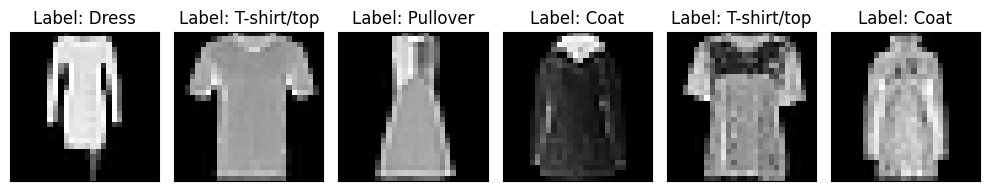

In [16]:
# get some random training images
dataiter = iter(train_dataloader)
images, labels = next(dataiter)
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(10, 8), subplot_kw={'xticks': [], 'yticks': []})
classes = train_set.classes
for i,ax in zip(range(0,6),axes.flat):
    img,label=images[i],labels[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {classes[label]}")

plt.tight_layout()
plt.show()

# Defining the Convolutional Neural Network

<img src='https://drive.google.com/uc?id=1Euy5_bGIiiYECSZUeEofgTImJWgQ0XLf'>

**<h2>Implement the model above in pytorch</h2>**

In [53]:
import torch.nn as nn
import torch.nn.functional as F

#define the CNN architecture below
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(2, 2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 64, 3, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2)
        )

        self.fully_connected = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6 * 6 * 64, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
#################################################################################
#                                   THE END                                     #
#################################################################################


    def forward(self, x):
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
        out = self.fully_connected(self.conv2(self.conv1(x)))

#################################################################################
#                                   THE END                                     #
#################################################################################

        return out

In [54]:
# Using GPU if it's available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [55]:
cnn_model = Net()
cnn_model.to(device)

Net(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fully_connected): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

# Defining Loss Function and optimizer
**Define appropriate Loss Function, Optimizer and Learning Rate**

In [57]:
import torch.optim as optim

Learning_rate= 10 ** -2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=Learning_rate)

**Define number of epochs and path to save the best model**

In [58]:
epochs = 25
save_path="./content/cnn_model.pt"

# Finally we will train our neural network

In [59]:
# multiclass accuracy
def multi_acc(y_pred, y_test):
    _, y_pred_tags = torch.max(y_pred, dim = 1)
    correct_pred = (y_pred_tags == y_test).float()
    acc = correct_pred.sum() / len(correct_pred)
    acc = torch.round(acc * 100)
    return acc

**Implementing the training algorithm and Saving the model with minimum Validation Loss**

In [60]:
# training loop
def train_model(model, train_dataloader, val_dataloader, n_epochs, optimizer, criterion, device, save_path):
    train_losses = []
    val_losses = []

    valid_loss_min = np.inf

    for epoch in range(n_epochs):
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
        ####### Training Phase ########
        model.train()
        train_loss = 0.0
        for image, label in train_dataloader:
            output = model(image)
            loss = criterion(output, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
      

        ####### Validation Phase ########
        model.eval()
        val_total_loss = 0.0
        with torch.no_grad():
            for image, label in val_dataloader:
                output = model(image)
                loss = criterion(output, label)
                val_total_loss += loss.item()

                    
        avg_train_loss = train_loss / len(train_dataloader)  
        valid_loss = val_total_loss / len(val_dataloader)

        train_losses.append(avg_train_loss)
        val_losses.append(valid_loss)   


#################################################################################
#                                   THE END                                     #
#################################################################################
        # print validation statistics
        print('Epoch: {}  Train Loss: {:.4f} Validation Loss: {:.4f}'.format(epoch+1, avg_train_loss, valid_loss))

        ## If the valiation loss has decreased, then saving the model
        if valid_loss <= valid_loss_min:
            print('Validation loss decreased ({:.4f} --> {:.4f}).  Saving model ...'.format(
            valid_loss_min,
            valid_loss))
            torch.save(model.state_dict(), save_path)
            valid_loss_min = valid_loss

    return model, train_losses, val_losses

**Train the model**

In [61]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
model, train_losses, val_losses = train_model(cnn_model, train_dataloader, val_dataloader, epochs, optimizer, criterion, device, save_path)
#################################################################################
#                                   THE END                                     #
#################################################################################

Epoch: 1  Train Loss: 0.5047 Validation Loss: 0.3681
Validation loss decreased (inf --> 0.3681).  Saving model ...
Epoch: 2  Train Loss: 0.3282 Validation Loss: 0.3566
Validation loss decreased (0.3681 --> 0.3566).  Saving model ...
Epoch: 3  Train Loss: 0.2942 Validation Loss: 0.3209
Validation loss decreased (0.3566 --> 0.3209).  Saving model ...
Epoch: 4  Train Loss: 0.2730 Validation Loss: 0.3296
Epoch: 5  Train Loss: 0.2561 Validation Loss: 0.2985
Validation loss decreased (0.3209 --> 0.2985).  Saving model ...
Epoch: 6  Train Loss: 0.2461 Validation Loss: 0.2947
Validation loss decreased (0.2985 --> 0.2947).  Saving model ...
Epoch: 7  Train Loss: 0.2415 Validation Loss: 0.3269
Epoch: 8  Train Loss: 0.2487 Validation Loss: 0.3340
Epoch: 9  Train Loss: 0.2355 Validation Loss: 0.2874
Validation loss decreased (0.2947 --> 0.2874).  Saving model ...
Epoch: 10  Train Loss: 0.2575 Validation Loss: 0.3129
Epoch: 11  Train Loss: 0.2162 Validation Loss: 0.2950
Epoch: 12  Train Loss: 0.210

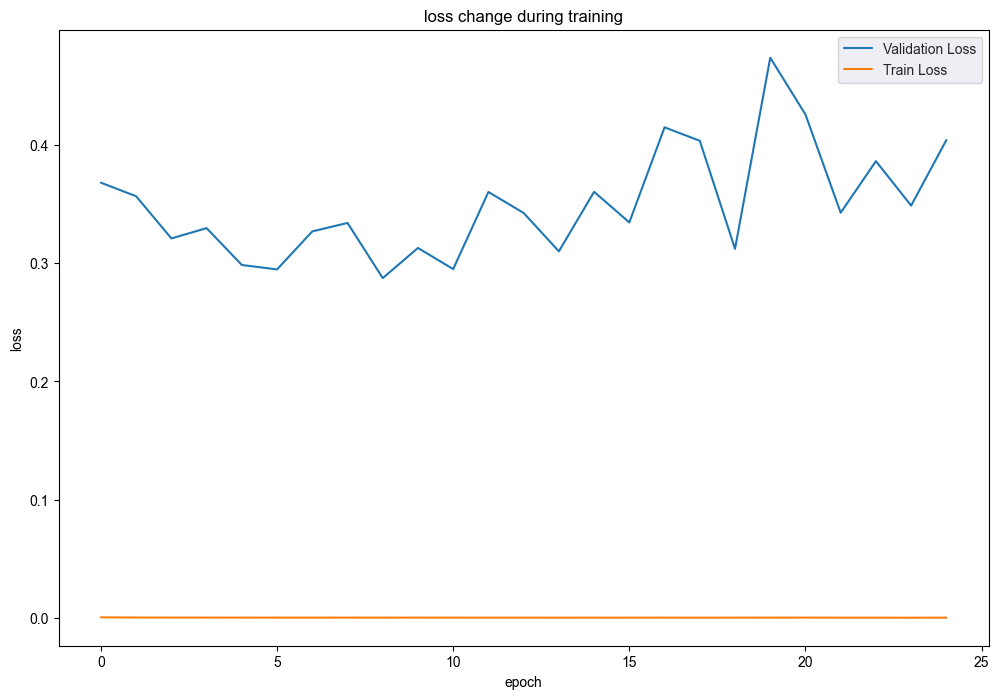

In [62]:
# plot losses
plt.subplots(figsize=(12, 8))
sns.set_style("dark")
sns.lineplot(data=val_losses,label="Validation Loss")
sns.lineplot(data=np.asarray(train_losses)/1000,label="Train Loss").set(title="loss change during training", xlabel="epoch", ylabel="loss")
plt.legend()
plt.show()

# Prediction on Test Data

In [64]:
cnn_model.load_state_dict(torch.load(save_path))
cnn_model.eval()

def predict(images, model):
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
    predicted = model(images).argmax(dim=1)

#################################################################################
#                                   THE END                                     #
#################################################################################
    return predicted

**Accuracy Result on Test Data**

In [65]:
correct = 0
total = 0
y_pred_list = []
y_true_list = []
with torch.no_grad():
    for data, labels in test_dataloader:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
        predicted = predict(data, cnn_model)
        
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
#################################################################################
#                                   THE END                                     #
#################################################################################
        for  x in predicted.cpu().numpy(): y_pred_list.append(x)
        for  x in labels.cpu().numpy(): y_true_list.append(x)

print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))

Accuracy of the network on the 10000 test images: 90 %


**Classification report**

In [66]:
print(classification_report(y_true_list, y_pred_list, target_names=classes))

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.81      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.82      0.89      0.85      1000
       Dress       0.93      0.87      0.90      1000
        Coat       0.86      0.84      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.77      0.74      1000
     Sneaker       0.93      0.98      0.95      1000
         Bag       0.95      0.99      0.97      1000
  Ankle boot       0.99      0.93      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



**Displaying a random set of images from test data**

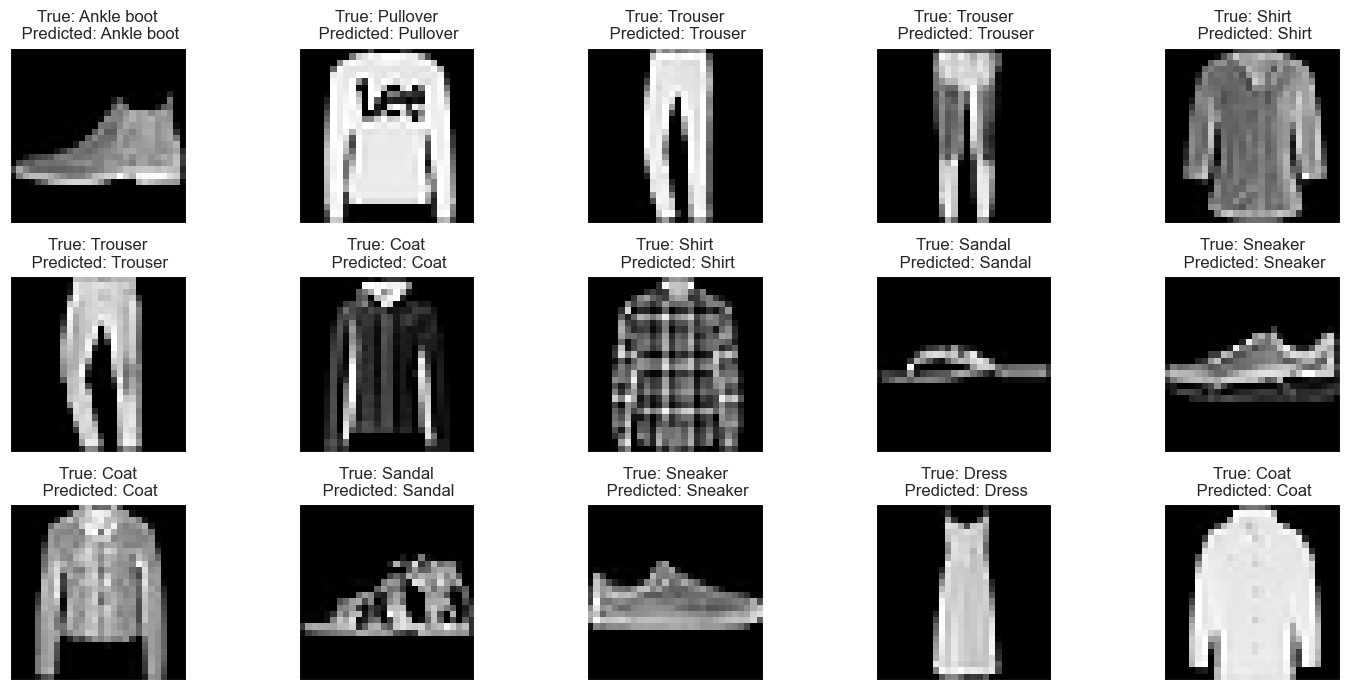

In [67]:
dataiter = iter(test_dataloader)
images, labels = next(dataiter)
predicted=predict(images,cnn_model)

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 7), subplot_kw={'xticks': [], 'yticks': []})
for i,ax in zip(range(0,16),axes.flat):
    img,label=images[i],labels[i]
    pred=predicted[i]
    ax.imshow(img.permute(1, 2, 0), cmap='gray')
    ax.set_title(f"True: {classes[label]}\n Predicted: {classes[pred]}")

plt.tight_layout()
plt.show()